# Dataset Exploration

Notebook này dùng để khám phá `ithieund/VietNews-Abs-Sum`, đo thống kê, kiểm tra chất lượng và xuất ghi chú phục vụ báo cáo.

In [14]:
from __future__ import annotations

import random
import statistics
import sys
import unicodedata
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

def find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'pyproject.toml').exists() or (candidate / 'requirements.txt').exists():
            return candidate
    return current

ROOT = find_repo_root()
SRC = ROOT / 'src'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

DATASET_NAME = 'ithieund/VietNews-Abs-Sum'
REPORTS_DIR = ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
EXAMPLES_DIR = REPORTS_DIR / 'examples'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXAMPLES_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8')

print(f'Seed: {SEED}')
print(f'Root: {ROOT}')
print(f'Dataset: {DATASET_NAME}')

Seed: 42
Root: /home/ductien/Documents/Transformer
Dataset: ithieund/VietNews-Abs-Sum


## 1. Load Dataset

In [15]:
ds = load_dataset(DATASET_NAME)
ds

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['guid', 'title', 'abstract', 'article'],
        num_rows: 303686
    })
    validation: Dataset({
        features: ['guid', 'title', 'abstract', 'article'],
        num_rows: 67010
    })
    test: Dataset({
        features: ['guid', 'title', 'abstract', 'article'],
        num_rows: 67640
    })
})

In [16]:
print('Splits:', list(ds.keys()))
for split_name, split in ds.items():
    print(split_name, len(split), split.column_names)

train_split = ds['train'] if 'train' in ds else next(iter(ds.values()))
print('\nFirst row keys:', list(train_split[0].keys()))

Splits: ['train', 'validation', 'test']
train 303686 ['guid', 'title', 'abstract', 'article']
validation 67010 ['guid', 'title', 'abstract', 'article']
test 67640 ['guid', 'title', 'abstract', 'article']

First row keys: ['guid', 'title', 'abstract', 'article']


## 2. Field Detection

VietNews có thể dùng `article`/`abstract`, nên notebook sẽ tự dò cột text thay vì hard-code `document`/`summary`.

In [17]:
DOCUMENT_KEYS = ['document', 'article', 'content', 'text', 'body', 'source', 'original']
SUMMARY_KEYS = ['summary', 'abstract', 'target', 'highlights', 'description']
TITLE_KEYS = ['title', 'headline']

def normalize_text(text: str) -> str:
    return unicodedata.normalize('NFC', ' '.join((text or '').split())).strip()

def pick_field(sample: dict, keys: list[str]) -> str:
    for key in keys:
        if key in sample and sample[key]:
            value = sample[key]
            if isinstance(value, dict):
                value = ' '.join(str(v) for v in value.values())
            elif isinstance(value, list):
                value = ' '.join(str(v) for v in value)
            return normalize_text(str(value))
    return ''

def get_text_fields(sample: dict) -> tuple[str, str, str]:
    title = pick_field(sample, TITLE_KEYS)
    document = pick_field(sample, DOCUMENT_KEYS)
    summary = pick_field(sample, SUMMARY_KEYS)
    return title, document, summary

title, document, summary = get_text_fields(train_split[0])
print('Detected title chars:', len(title))
print('Detected document chars:', len(document))
print('Detected summary chars:', len(summary))
print('Title preview:', title[:120])
print('Document preview:', document[:200])
print('Summary preview:', summary[:200])

Detected title chars: 85
Detected document chars: 1575
Detected summary chars: 178
Title preview: Khởi_tố kẻ_trộm hơn 1 tạ thóc và hơn 8 triệu đồng của chú ruột để lấy tiền mua ma_tuý
Document preview: Ngày 27/3 , Cơ_quan Cảnh_sát điều_tra Công_an TP. Hưng_Yên , tỉnh Hưng_Yên cho biết , đơn_vị vừa ra quyết_định khởi_tố vụ án , khởi_tố bị_can đối_với đối_tượng Mai_Văn_Thương ( SN 1989 , trú tại đội 1
Summary preview: Với bản_tính ham chơi , lười làm , có nhiều tiền_án tiền_sự , lại nghiện ma_tuý , Thương đã đột_nhập vào nhà chú ruột để trộm hơn 1 tạ thóc và hơn 8 triệu đồng mang đi tiêu_xài .


## 3. Single Sample Inspection

In [18]:
def show_sample(sample: dict, title: str) -> None:
    sample_title, document, summary = get_text_fields(sample)
    print(f'=== {title} ===')
    if sample_title:
        print('Title chars:', len(sample_title))
        print('Title preview:', sample_title[:120])
    print('Document chars:', len(document))
    print('Summary chars:', len(summary))
    print('\nDocument preview:')
    print(document[:800])
    print('\nSummary preview:')
    print(summary[:400])
    print('\n' + '-' * 80)

for split_name in ds.keys():
    show_sample(ds[split_name][0], f'{split_name} sample[0]')

=== train sample[0] ===
Title chars: 85
Title preview: Khởi_tố kẻ_trộm hơn 1 tạ thóc và hơn 8 triệu đồng của chú ruột để lấy tiền mua ma_tuý
Document chars: 1575
Summary chars: 178

Document preview:
Ngày 27/3 , Cơ_quan Cảnh_sát điều_tra Công_an TP. Hưng_Yên , tỉnh Hưng_Yên cho biết , đơn_vị vừa ra quyết_định khởi_tố vụ án , khởi_tố bị_can đối_với đối_tượng Mai_Văn_Thương ( SN 1989 , trú tại đội 11 , thôn An_Chiểu 1 , xã Liên_Phương , TP. Hưng_Yên ) để điều_tra về hành_vi trộm_cắp tài_sản . Theo tài_liệu điều_tra của cơ_quan công_an , vào_khoảng 7h30 ngày 13/3 , lợi_dụng gia_đình ông Mai_Văn_Thịnh ( chú ruột đối_tượng Thương ) ở cạnh nhà đi vắng , đối_tượng này đã đạp gãy chấn_song cửa_sổ , đột_nhập vào nhà ông Thịnh trộm_cắp 121kg thóc mang bán cho người cùng thôn lấy 700.000 đ . Không dừng lại , sau đó đối_tượng tiếp_tục quay lại lục_soát tủ nhà ông Thịnh trộm_cắp 8.500.000 đ tiền_mặt ( ông Thịnh để dưới đáy tủ ) , rồi dùng số tiền trên để đi mua ma_tuý về sử_dụng và tiêu_xài hết 6.0

## 4. Random Sample Review

Chọn ngẫu nhiên 20 sample để đọc nhanh và ghi chú chất lượng dữ liệu.

In [19]:
sample_count = min(20, len(train_split))
indices = random.sample(range(len(train_split)), sample_count)
review_rows = []

for idx in indices:
    sample = train_split[idx]
    title, document, summary = get_text_fields(sample)
    review_rows.append({
        'index': idx,
        'title': title[:120],
        'doc_chars': len(document),
        'sum_chars': len(summary),
        'doc_preview': document[:250].replace('\n', ' '),
        'sum_preview': summary[:180].replace('\n', ' '),
    })

pd.DataFrame(review_rows)

,index,title,doc_chars,sum_chars,doc_preview,sum_preview
0,58369,Tranh_cãi chuyện ' ăn thịt chó ' : Khi trót yê...,3968,181,"Mấy năm trở_lại đây , "" Thịt chó – Ăn hay khôn...",""" Xét cho cùng , chó cũng là một loài động_vật..."
1,13112,Đà_Nẵng lo_ngại 8 khu_tập_thể chờ sập,1663,163,"Ngày 17-1 , UBND TP Đà_Nẵng cho_biết vừa có cô...",Hiện các nhà_tập_thể này đang được cơ_quan quả...
2,144194,Tiêm kích Nga xuất hiện trong hình quảng cáo c...,1436,134,Hình ảnh được đăng trên tài khoản của Bộ Thươn...,Bộ Thương mại Quốc tế Anh phải xoá bài đăng tr...
3,128393,Ván bài của Nga khi dập tắt toan tính của Thổ ...,3536,181,"Theo Financial Times , quyết định rút quân khỏ...",Thổ Nhĩ Kỳ muốn tiêu diệt người Kurd ở Bắc Syr...
4,117026,Cách chức phó chủ tịch xã bán đất rừng,1782,128,"Liên quan vụ bán đất rừng tại xã Phước Vinh , ...","Phó chủ tịch UBND xã Phước Vinh , huyện Ninh P..."
5,73158,Hơn 100 thầy_cô tiếng Pháp gặp nhau ở Tổng_lãn...,2066,122,Buổi gặp_mặt được tổ_chức tại khu_vực sảnh toà...,"Tối 20-11 , hơn 100 giáo_viên dạy tiếng Pháp ở..."
6,53736,Trung_Quốc khó_chịu vì Nhật chờ_đợi phán_quyết...,1861,124,Phát_ngôn_viên Bộ Ngoại_giao Trung_Quốc Hồng_L...,"Trung_Quốc yêu_cầu Nhật_Bản không "" thổi_phồng..."
7,285929,Bê_bối quay lén ở Hàn_Quốc : ' Xin cánh đàn_ôn...,3396,188,"Đầu năm 2019 , cả nước Hàn rúng_động với vụ bê...",Những than_thở có phần chua_chát của phụ_nữ Hà...
8,45580,"Phần_lớn cử_tri trung_niên , cao_tuổi bỏ_phiếu...",932,111,Khảo_sát tỷ_lệ ủng_hộ của cử_tri theo độ tuổi ...,Khảo_sát sau bầu_cử của kênh_truyền_hình CNN c...
9,221208,Bắt được kẻ giết người sau 39 năm nhờ dữ_liệu ...,2673,99,"Ngày 19-12-1979 , Michelle_Martinko , 18 tuổi ...","Nhờ một kỹ_thuật có tên gọi phả hệ di_truyền ,..."


Ghi chú thủ công:
- sample quá ngắn
- summary quá chung chung
- có lặp ý
- lỗi encoding/dấu tiếng Việt
- domain gap với meeting/lecture notes

## 5. Statistics

In [20]:
def split_stats(split) -> tuple[dict, list[int], list[int]]:
    doc_lengths = []
    sum_lengths = []
    ratios = []
    for item in split:
        _, document, summary = get_text_fields(item)
        doc_len = len(document)
        sum_len = len(summary)
        doc_lengths.append(doc_len)
        sum_lengths.append(sum_len)
        ratios.append(sum_len / max(doc_len, 1))
    stats = {
        'count': len(split),
        'doc_mean': round(statistics.mean(doc_lengths), 2),
        'doc_median': round(statistics.median(doc_lengths), 2),
        'doc_min': min(doc_lengths),
        'doc_max': max(doc_lengths),
        'sum_mean': round(statistics.mean(sum_lengths), 2),
        'sum_median': round(statistics.median(sum_lengths), 2),
        'sum_min': min(sum_lengths),
        'sum_max': max(sum_lengths),
        'ratio_mean': round(statistics.mean(ratios), 4),
    }
    return stats, doc_lengths, sum_lengths

stats_rows = []
all_doc_lengths = {}
all_sum_lengths = {}

for split_name, split in ds.items():
    stats, doc_lengths, sum_lengths = split_stats(split)
    stats_rows.append({'split': split_name, **stats})
    all_doc_lengths[split_name] = doc_lengths
    all_sum_lengths[split_name] = sum_lengths

stats_df = pd.DataFrame(stats_rows)
stats_df

,split,count,doc_mean,doc_median,doc_min,doc_max,sum_mean,sum_median,sum_min,sum_max,ratio_mean
0,train,303686,2292.51,1975.0,162,12134,157.77,148.0,30,658,0.0840
1,validation,67010,2306.53,1989.0,197,11439,158.66,150.0,32,628,0.0839
2,test,67640,2307.30,1991.0,138,10481,159.16,150.0,48,498,0.0843


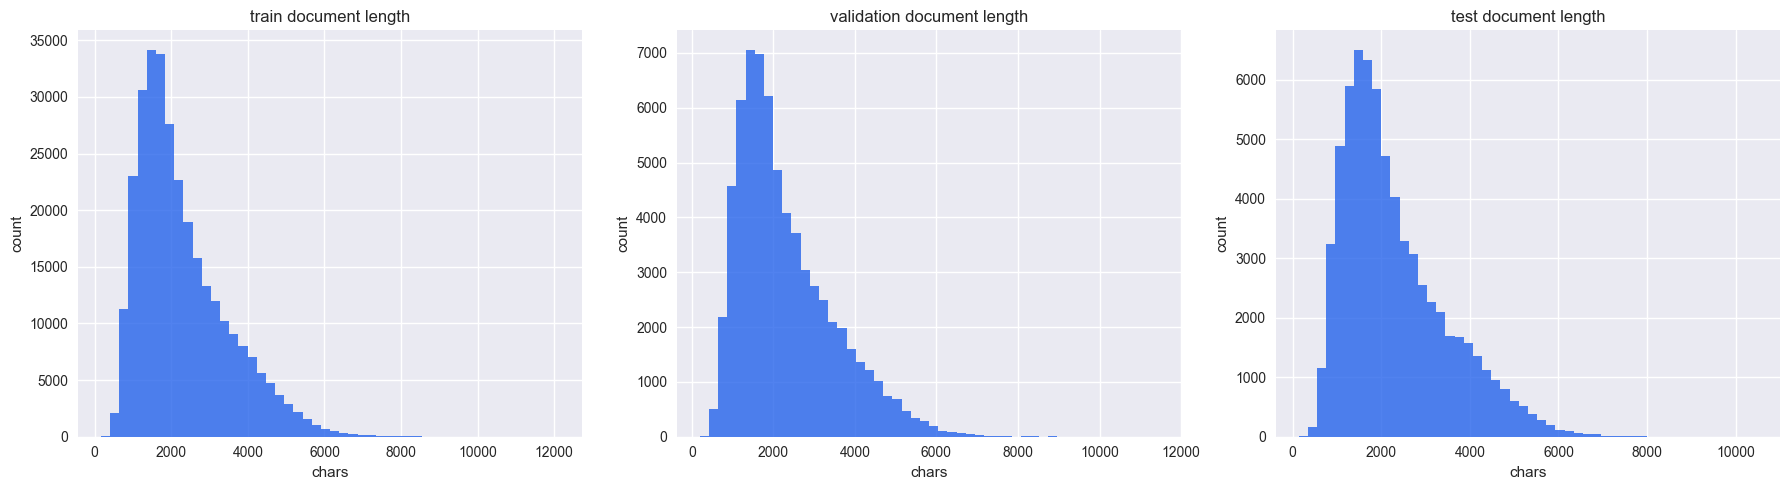

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (split_name, lengths) in zip(axes, all_doc_lengths.items()):
    ax.hist(lengths, bins=50, color='#2563eb', alpha=0.8)
    ax.set_title(f'{split_name} document length')
    ax.set_xlabel('chars')
    ax.set_ylabel('count')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dataset_length_histograms.png', dpi=200, bbox_inches='tight')
plt.show()

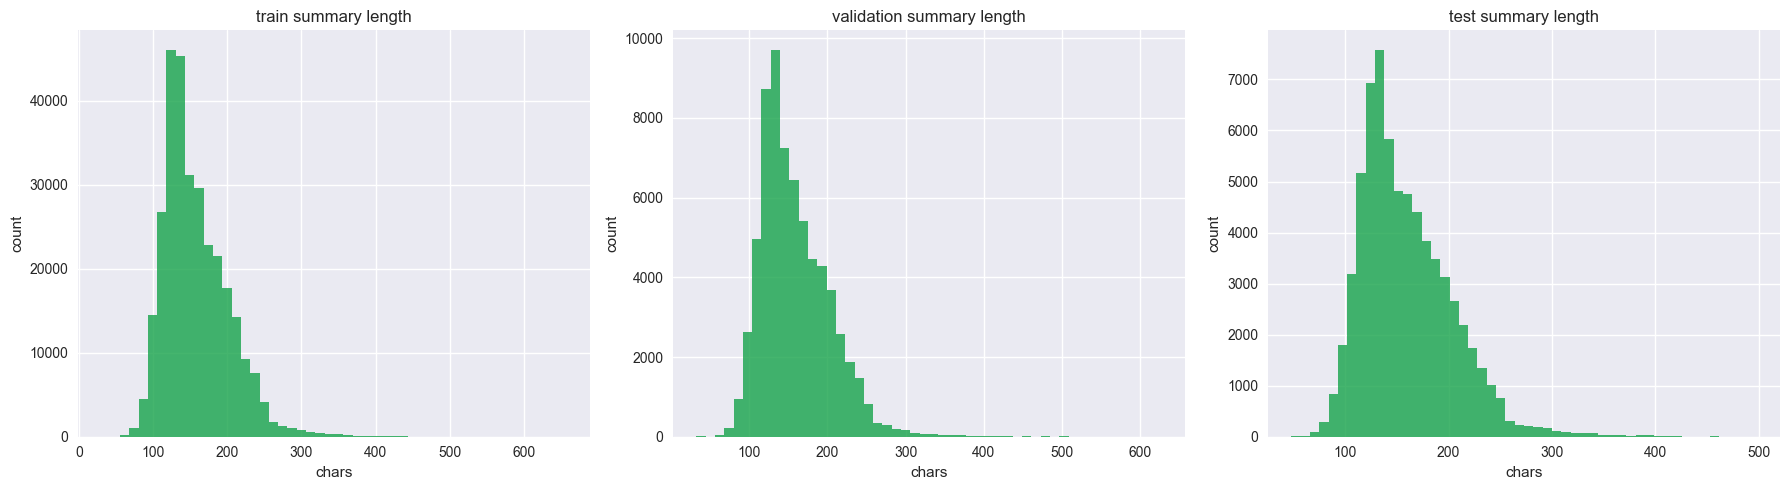

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (split_name, lengths) in zip(axes, all_sum_lengths.items()):
    ax.hist(lengths, bins=50, color='#16a34a', alpha=0.8)
    ax.set_title(f'{split_name} summary length')
    ax.set_xlabel('chars')
    ax.set_ylabel('count')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'summary_length_histograms.png', dpi=200, bbox_inches='tight')
plt.show()

/tmp/ipykernel_125830/1942348899.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([all_doc_lengths[s] for s in ds.keys()], labels=list(ds.keys()), showfliers=False)


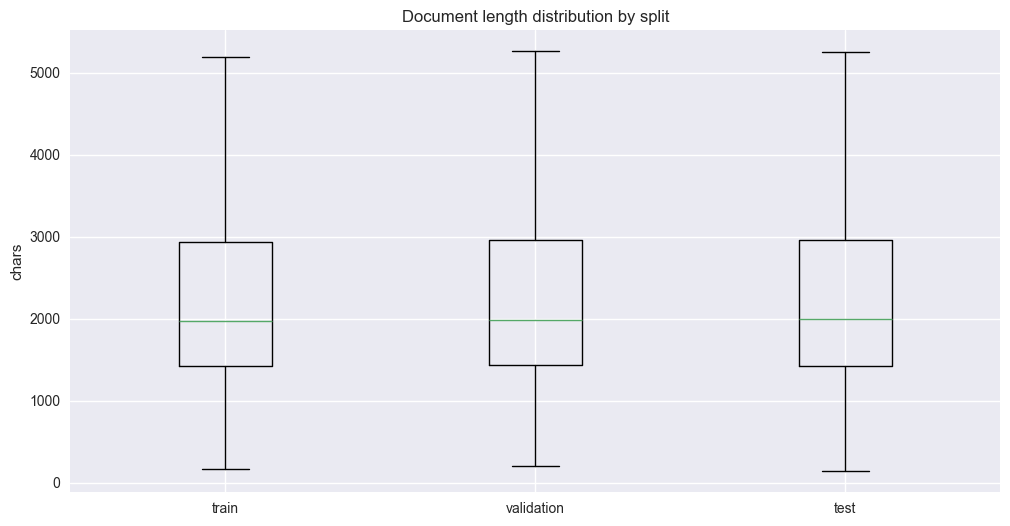

In [23]:
plt.figure(figsize=(12, 6))
plt.boxplot([all_doc_lengths[s] for s in ds.keys()], labels=list(ds.keys()), showfliers=False)
plt.title('Document length distribution by split')
plt.ylabel('chars')
plt.savefig(FIGURES_DIR / 'dataset_length_boxplot.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Quality Checks

In [24]:
def quality_flags(sample: dict) -> list[str]:
    flags = []
    title, document, summary = get_text_fields(sample)
    if not document or not summary:
        flags.append('empty')
    if len(document) < 50:
        flags.append('doc_too_short')
    if len(document) > 10000:
        flags.append('doc_too_long')
    if len(summary) < 10:
        flags.append('summary_too_short')
    if document == summary:
        flags.append('doc_equals_summary')
    if document != unicodedata.normalize('NFC', document):
        flags.append('unicode_normalization')
    return flags

quality_counter = Counter()
for split_name, split in ds.items():
    for item in split:
        for flag in quality_flags(item):
            quality_counter[f'{split_name}:{flag}'] += 1

train_titles = Counter(get_text_fields(item)[0] for item in train_split)
train_documents = Counter(get_text_fields(item)[1] for item in train_split)
train_summaries = Counter(get_text_fields(item)[2] for item in train_split)

duplicate_title_groups = sum(1 for text, count in train_titles.items() if text and count > 1)
duplicate_document_groups = sum(1 for text, count in train_documents.items() if text and count > 1)
duplicate_summary_groups = sum(1 for text, count in train_summaries.items() if text and count > 1)
duplicate_document_rows = sum(count - 1 for text, count in train_documents.items() if text and count > 1)
duplicate_summary_rows = sum(count - 1 for text, count in train_summaries.items() if text and count > 1)

quality_counter, duplicate_title_groups, duplicate_document_groups, duplicate_summary_groups, duplicate_document_rows, duplicate_summary_rows

(Counter({'train:doc_too_long': 21,
          'validation:doc_too_long': 3,
          'test:doc_too_long': 3}),
 99163,
 99181,
 99180,
 102508,
 102853)

## 7. Export Notes

Cell này ghi thống kê và sample đẹp ra `reports/examples/dataset_notes.md`.

In [25]:
good_examples = []
for idx in indices[:5]:
    sample = train_split[idx]
    title, document, summary = get_text_fields(sample)
    good_examples.append({
        'index': idx,
        'title': title,
        'document': document[:1200],
        'summary': summary[:500],
    })

notes_path = EXAMPLES_DIR / 'dataset_notes.md'
with notes_path.open('w', encoding='utf-8') as f:
    f.write('# Dataset Notes\n\n')
    f.write('## Statistics\n\n')
    f.write(stats_df.to_markdown(index=False))
    f.write('\n\n## Quality Checks\n\n')
    for key, value in quality_counter.items():
        f.write(f'- {key}: {value}\n')
    f.write(f'\n- duplicate_title_groups: {duplicate_title_groups}\n')
    f.write(f'- duplicate_document_groups: {duplicate_document_groups}\n')
    f.write(f'- duplicate_summary_groups: {duplicate_summary_groups}\n')
    f.write(f'- duplicate_document_rows: {duplicate_document_rows}\n')
    f.write(f'- duplicate_summary_rows: {duplicate_summary_rows}\n')
    f.write('\n## Insights\n\n')
    f.write('- VietNews is large and suitable as the main summarization base.\n')
    f.write('- Document lengths are right-skewed with a long tail, so max length control is important.\n')
    f.write('- Summary lengths are compact and centered around 150 characters, which fits abstractive summarization well.\n')
    f.write('- Duplicate articles are common, so training may memorize frequent news patterns if we do not deduplicate or at least sample carefully.\n')
    f.write('- The dataset is still useful, but phase 2 synthetic adaptation is valuable because news style differs from meeting/lecture style.\n')
    f.write('\n## Good Examples\n\n')
    for item in good_examples:
        f.write(f"### Sample {item['index']}\n\n")
        if item['title']:
            f.write(f"Title: {item['title']}\n\n")
        f.write('Document:\n\n')
        f.write(item['document'] + '\n\n')
        f.write('Summary:\n\n')
        f.write(item['summary'] + '\n\n')

print(f'Wrote notes to {notes_path}')
print(f'Figures saved in {FIGURES_DIR}')

Wrote notes to /home/ductien/Documents/Transformer/reports/examples/dataset_notes.md
Figures saved in /home/ductien/Documents/Transformer/reports/figures


## 8. Decision Section

Viết kết luận ngắn cho báo cáo:
- VietNews có đủ sạch để dùng làm dataset chính không
- domain gap với meeting/lecture notes lớn đến đâu
- có cần filter mạnh không
- có cần fallback dataset không

## 9. Sources to Read

- Hugging Face Datasets: https://huggingface.co/docs/datasets
- Pandas basics: https://pandas.pydata.org/docs/getting_started/index.html
- VietNews dataset: https://huggingface.co/datasets/ithieund/VietNews-Abs-Sum